<a href="https://colab.research.google.com/github/harshitha020505/DLLAB/blob/main/DLLAB10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

transform = transforms.ToTensor()

train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

In [ ]:
class UndercompleteAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.decoder(self.encoder(x))

In [ ]:
class OvercompleteAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Linear(1024, 900)
        )
        self.decoder = nn.Sequential(
            nn.Linear(900, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.decoder(self.encoder(x))

In [ ]:
def train(model, epochs=5, wd=0):
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=wd)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        for img, _ in train_loader:
            out = model(img)
            loss = loss_fn(out, img.view(-1, 784))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

def show(model):
    model.eval()
    with torch.no_grad():
        imgs, _ = next(iter(test_loader))
        out = model(imgs)

        imgs = imgs.view(-1,28,28)
        out = out.view(-1,28,28)

        plt.figure(figsize=(10,4))
        for i in range(5):
            plt.subplot(2,5,i+1)
            plt.imshow(imgs[i], cmap='gray')
            plt.axis('off')

            plt.subplot(2,5,i+6)
            plt.imshow(out[i], cmap='gray')
            plt.axis('off')
        plt.show()

Epoch 1, Loss: 0.0261
Epoch 2, Loss: 0.0172
Epoch 3, Loss: 0.0155
Epoch 4, Loss: 0.0129
Epoch 5, Loss: 0.0123


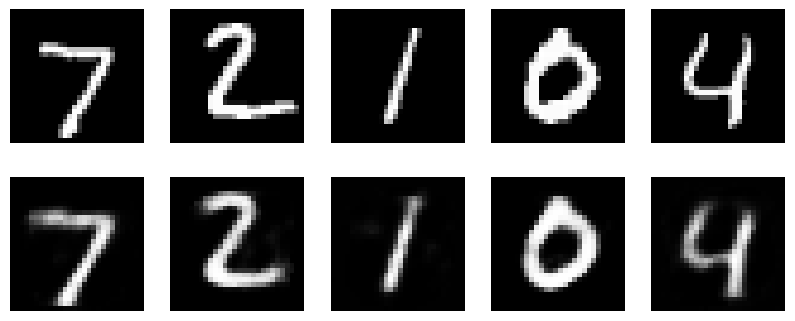

In [ ]:
model_reg = UndercompleteAE()
train(model_reg, wd=1e-5)
show(model_reg)

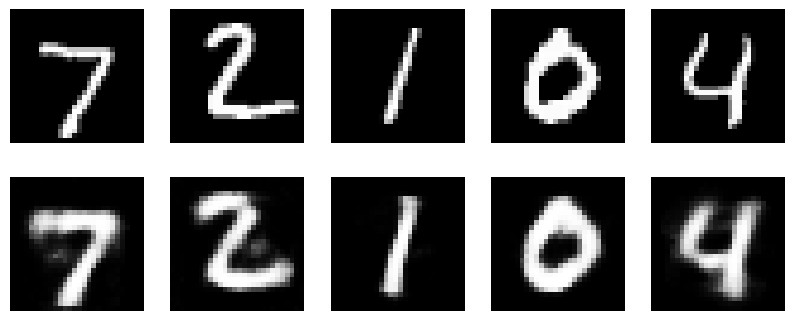

In [ ]:
def add_noise(x, noise_level=0.5):
    noise = noise_level * torch.randn_like(x)
    return torch.clamp(x + noise, 0., 1.)

class DenoiseAE(UndercompleteAE):
    pass

def train_denoise(model):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(5):
        for img, _ in train_loader:
            noisy = add_noise(img)
            out = model(noisy)
            loss = loss_fn(out, img.view(-1,784))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

model_dn = DenoiseAE()
train_denoise(model_dn)
show(model_dn)

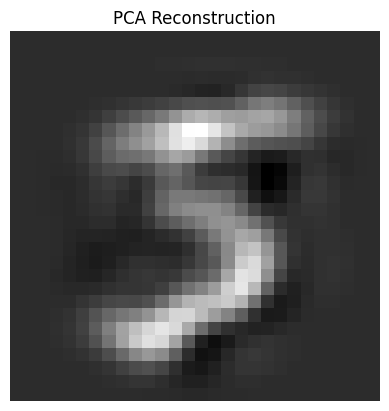

In [ ]:
data = train_data.data.view(-1,784).float().numpy()

pca = PCA(n_components=32)
reduced = pca.fit_transform(data)
recon = pca.inverse_transform(reduced)

plt.imshow(recon[0].reshape(28,28), cmap='gray')
plt.title("PCA Reconstruction")
plt.axis('off')
plt.show()

In [ ]:
class SparseAE(UndercompleteAE):
    def forward(self, x):
        x = x.view(-1,784)
        z = self.encoder(x)
        self.sparsity = torch.mean(z)
        return self.decoder(z)

In [ ]:
class ContractiveAE(UndercompleteAE):
    def loss(self, x, out):
        mse = nn.MSELoss()(out, x.view(-1,784))
        W = self.encoder[0].weight
        return mse + 1e-4 * torch.sum(W**2)